In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
import gymnasium
import mountain


Load trajectories

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment mountain/GridWorld-v1 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(
<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


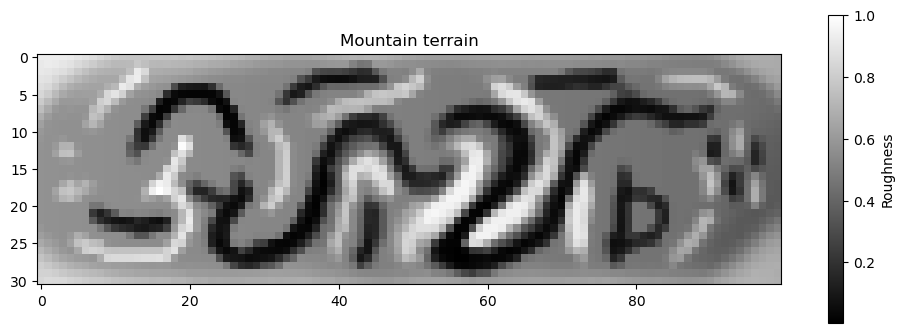

In [2]:
with open("trajectories.pickle", "rb") as f:
    trajectories = pickle.load(f)

ROWS, COLS = 31, 100


#The map
env = gymnasium.make('mountain/GridWorld-v1')
terrain = env.unwrapped.MAP

plt.figure(figsize=(12,4))
plt.imshow(terrain, cmap="gray", origin="upper")
plt.colorbar(label="Roughness")
plt.title("Mountain terrain")
plt.show()

What task 5.1 is asking:

Use the recorded robot trajectories to estimate how good each state is under the unknown policy 𝜋 by averaging the total reward observed after visiting that state.

What the method returns:
The MC state-value function mc_eval_V returns a mapping from each state s to the estimated expected cumulative reward obtained when starting from s and following policy π.

Task 1:

MC evaluation for vπ(s)

In [3]:
def mc_eval_V(trajectories, gamma=1.0, first_visit=True):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    for episode in trajectories:
        # episode is a list of (s, a, r, s_next)
        states = [step[0] for step in episode]
        rewards = [float(step[2]) for step in episode]  # r_t

        # compute returns G_t backwards
        G = 0.0
        returns = [0.0] * len(rewards)
        for t in reversed(range(len(rewards))):
            G = rewards[t] + gamma * G
            returns[t] = G

        visited = set()
        for t, s in enumerate(states):
            if first_visit and s in visited:
                continue
            visited.add(s)
            returns_sum[s] += returns[t]
            returns_count[s] += 1

    V = {s: returns_sum[s] / returns_count[s] for s in returns_sum}
    return V

In [4]:
V = mc_eval_V(trajectories, gamma=1.0, first_visit=True)
print("Number of states estimated:", len(V))
print("V((15,0)):", V.get((15,0)))

Number of states estimated: 2924
V((15,0)): -78.13585565252045


Task 2:

What the question asks:

Use the same trajectories to estimate how good each state–action pair is under policy 𝜋 by averaging the total reward observed after taking action 𝑎 in state 𝑠.

What the method returns:

The MC action-value function mc_eval_Q returns a mapping from each state–action pair (s,a) to the estimated expected cumulative reward obtained when starting from s, taking action a, and then following policy π.

In [5]:
def mc_eval_Q(trajectories, gamma=1.0, first_visit=True):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    for episode in trajectories:
        states = [step[0] for step in episode]
        actions = [int(step[1]) for step in episode]
        rewards = [float(step[2]) for step in episode]

        G = 0.0
        returns = [0.0] * len(rewards)
        for t in reversed(range(len(rewards))):
            G = rewards[t] + gamma * G
            returns[t] = G

        visited = set()
        for t, (s, a) in enumerate(zip(states, actions)):
            key = (s, a)
            if first_visit and key in visited:
                continue
            visited.add(key)
            returns_sum[key] += returns[t]
            returns_count[key] += 1

    Q = {k: returns_sum[k] / returns_count[k] for k in returns_sum}
    return Q

In [6]:
Q = mc_eval_Q(trajectories, gamma=1.0, first_visit=True)
print("Number of (s,a) estimated:", len(Q))
print("Q((15,0),0):", Q.get(((15,0),0)))

Number of (s,a) estimated: 14138
Q((15,0),0): -77.43312773207876


In [7]:
V_grid = np.full((ROWS, COLS-1), np.nan)

for (i, j), v in V.items():
    V_grid[i, j] = v

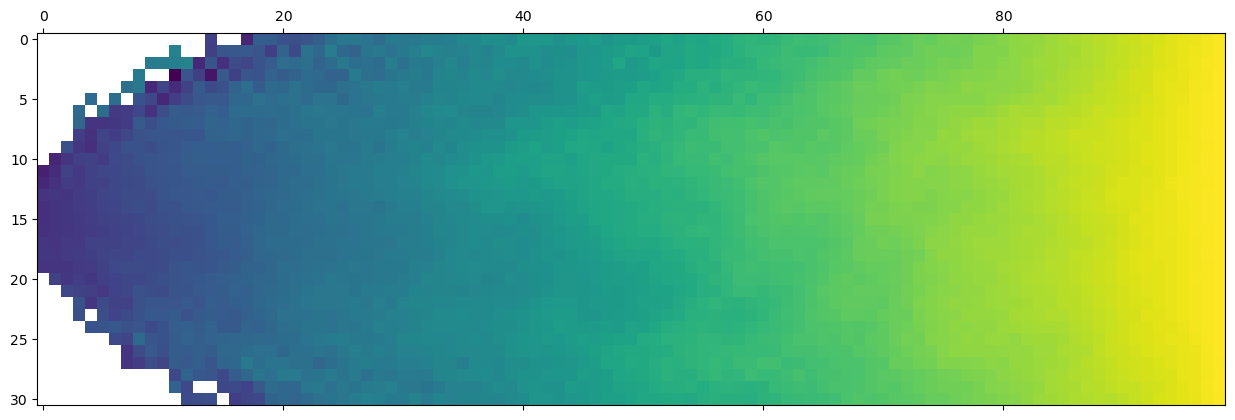

In [8]:
plt.matshow(V_grid)
# plt.figure(figsize=(12,4))
# plt.imshow(V_grid, cmap="viridis", origin="upper")
# plt.colorbar(label="vπ(s)")
# plt.title("Monte Carlo vπ(s) (only visited states)")
plt.show()

Task 4:

In [9]:
def mc_improve_policy_from_Q(Q, default_action=0):
    """
    Q: dict with keys ((i,j), a) -> q value
    returns: policy array (ROWS,COLS) with action indices
    """
    pi_new = np.full((ROWS, COLS), default_action, dtype=int)

    # group Q-values by state
    q_by_state = defaultdict(dict)
    for (s, a), q in Q.items():
        q_by_state[s][a] = q

    # choose best observed action in each visited state
    for s, qdict in q_by_state.items():
        best_a = max(qdict, key=qdict.get)
        pi_new[s] = best_a

    return pi_new

pi_new = mc_improve_policy_from_Q(Q, default_action=0)

measure how many states you actually improved:

In [10]:
visited_states = {s for (s,a) in Q.keys()}
print("States with at least one Q estimate:", len(visited_states), "out of", ROWS*COLS)

States with at least one Q estimate: 2924 out of 3100


Load the first version of the environment mountain (v1)

In [11]:
env = gymnasium.make('mountain/GridWorld-v1')

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment mountain/GridWorld-v1 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


Task 7:

Choosing a starting policy -> Uniform random policy
- guarantees exploration
- unbiased (does not assume knowledge of terrain)
- ensures MC control can learn all state–action values


In [12]:
env = gymnasium.make("mountain/GridWorld-v1")
N_ACTIONS = env.action_space.n

def obs_to_state(obs):
    # obs looks like: {"agent": {"pos": array([row, col])}}
    r, c = obs["agent"]["pos"]
    return (int(r), int(c))

def epsilon_greedy(Q, s, eps):
    if np.random.rand() < eps:
        return np.random.randint(N_ACTIONS)
    return int(np.argmax(Q[s]))

def mc_control(env, episodes=20000, gamma=1.0, eps_start=1.0, eps_end=0.05, eps_decay=0.999):
    # Q and counts: shape (rows, cols, actions)
    n_rows, n_cols = env.unwrapped.MAP.shape
    Q = np.zeros((n_rows, n_cols, N_ACTIONS), dtype=np.float64)
    N = np.zeros((n_rows, n_cols, N_ACTIONS), dtype=np.int32)

    eps = eps_start

    best_episode = None
    best_return = -np.inf

    for ep in range(episodes):
        obs, _ = env.reset()
        episode = []  # [(s, a, r), ...]

        done = False
        while not done:
            s = obs_to_state(obs)
            a = epsilon_greedy(Q, s, eps)
            obs2, r, terminated, truncated, _ = env.step(a)
            episode.append((s, a, float(r)))
            obs = obs2
            done = terminated or truncated

        # track best episode (by total return)
        G_total = sum(r for (_, _, r) in episode)
        if G_total > best_return:
            best_return = G_total
            best_episode = episode

        # First-visit MC update
        G = 0.0
        seen = set()
        for (s, a, r) in reversed(episode):
            G = gamma * G + r
            if (s, a) in seen:
                continue
            seen.add((s, a))
            r0, c0 = s
            N[r0, c0, a] += 1
            Q[r0, c0, a] += (G - Q[r0, c0, a]) / N[r0, c0, a]

        eps = max(eps_end, eps * eps_decay)

    return Q, best_episode, best_return

Q, best_episode, best_return = mc_control(env, episodes=30000)
print("Best return seen during training:", best_return)

c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Best return seen during training: -33.18277651477369


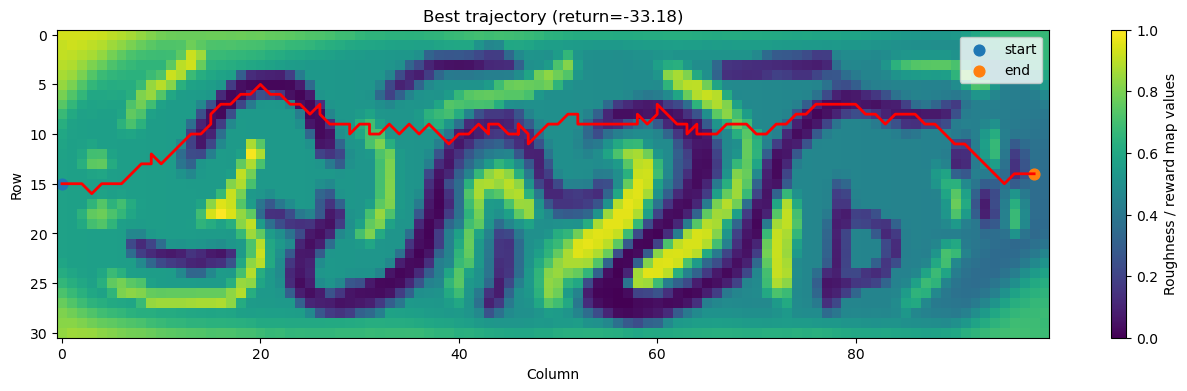

In [15]:
def plot_episode_on_map(env, episode, title="Trajectory"):
    mountain_map = env.unwrapped.MAP
    path_states = [s for (s, a, r) in episode]

    rows = [s[0] for s in path_states]
    cols = [s[1] for s in path_states]

    plt.figure(figsize=(16, 4))
    plt.imshow(mountain_map, aspect="auto", origin="upper")
    plt.plot(cols, rows, linewidth=2, c= "r")
    plt.scatter([cols[0]], [rows[0]], s=60, label="start")
    plt.scatter([cols[-1]], [rows[-1]], s=60, label="end")
    plt.title(title)
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.colorbar(label="Roughness / reward map values")
    plt.legend()
    plt.show()

plot_episode_on_map(env, best_episode, title=f"Best trajectory (return={best_return:.2f})")